In [ ]:
''' Analysis for MOL 290 Project
'''

In [2]:
# import libraries 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

In [ ]:
# load data
mutations = pd.read_csv('OmicsSomaticMutations.csv', index_col=None, usecols=['ModelID', 'ModelConditionID',
                                                                              'chrom', 'Pos', 'Ref', 
                                                                              'RefCount', 'AltCount', 'VariantType', 
                                                                              'ProteinChange', 'GwasDisease',
                                                                              'LikelyLoF', 'CivicDescription'])

/var/folders/rs/xc4337f52bb522klqqm67g8m0000kr/T/ipykernel_25122/4001043157.py:1: DtypeWarning: Columns (28,52,56,58,59,61) have mixed types. Specify dtype option on import or set low_memory=False.
  mutations = pd.read_csv('OmicsSomaticMutations.csv', index_col=None)


In [3]:
# load data
expression = pd.read_csv('biostats_final_project/data/OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv')
profiles = pd.read_csv('biostats_final_project/data/OmicsProfiles.csv', index_col=None)

In [4]:
# create df with COL9A2
df = expression[['ModelID', 'COL9A2 (1298)']].copy()

In [5]:
# rename column
df = df.rename(columns={'COL9A2 (1298)':'COL9A2'})

In [6]:
profiles.head()

,ModelID,IsDefaultEntryForModel,StrippedCellLineName,DepMapCode,Lineage,ModelConditionID,IsDefaultEntryForMC,SourceModelCondition,CellFormat,GrowthMedia,GrowthPattern,ProfileID,SequencingPlatform,SequencingID,DataType,Stranded,SharedToDbGaP,SequencingDate
0,ACH-000001,Yes,NIHOVCAR3,HGSOC,Ovary/Fallopian Tube,MC-000001-ztiA,Yes,BROAD,adherent,MF-001-041,Adherent,PR-vFBZ2h,NaN,CDS-VqxBGH,rna,False,False,2013-01-01
1,ACH-000001,Yes,NIHOVCAR3,HGSOC,Ovary/Fallopian Tube,MC-000001-ztiA,Yes,BROAD,adherent,MF-001-041,Adherent,PR-sbeUkh,NaN,CDS-1pLoxn,wgs,False,False,2013-03-21
2,ACH-000001,No,NIHOVCAR3,HGSOC,Ovary/Fallopian Tube,MC-000001-ZU8p,Yes,SANGER,adherent,NaN,Adherent,PR-99siqG,NaN,CDS-C3gZIu,wes,False,False,NaN
3,ACH-000013,Yes,ONCODG1,HGSOC,Ovary/Fallopian Tube,MC-000013-MIEW,Yes,BROAD,adherent,MF-001-001,Adherent,PR-gXHYvm,NaN,CDS-qqF7T8,rna,False,False,2013-01-25
4,ACH-000013,No,ONCODG1,HGSOC,Ovary/Fallopian Tube,MC-000013-MIEW,No,BROAD,adherent,MF-001-001,Adherent,PR-yFRI6x,NaN,CDS-FvwPIb,wes,False,False,2012-03-03


In [7]:
profile_df = profiles[['ModelID', 'Lineage', 'SourceModelCondition',
                       'CellFormat', 'GrowthPattern']].copy()

In [8]:
merged = pd.merge(df, profile_df, on='ModelID', how='left')

In [9]:
merged.head()

,ModelID,COL9A2,Lineage,SourceModelCondition,CellFormat,GrowthPattern
0,ACH-001113,1.584077,Lung,BROAD,adherent,Adherent
1,ACH-001113,1.584077,Lung,BROAD,adherent,Adherent
2,ACH-001289,0.000000,CNS/Brain,BROAD,suspension,Suspension
3,ACH-001289,0.000000,CNS/Brain,BROAD,suspension,Suspension
4,ACH-001339,0.644727,Skin,BROAD,adherent,Adherent


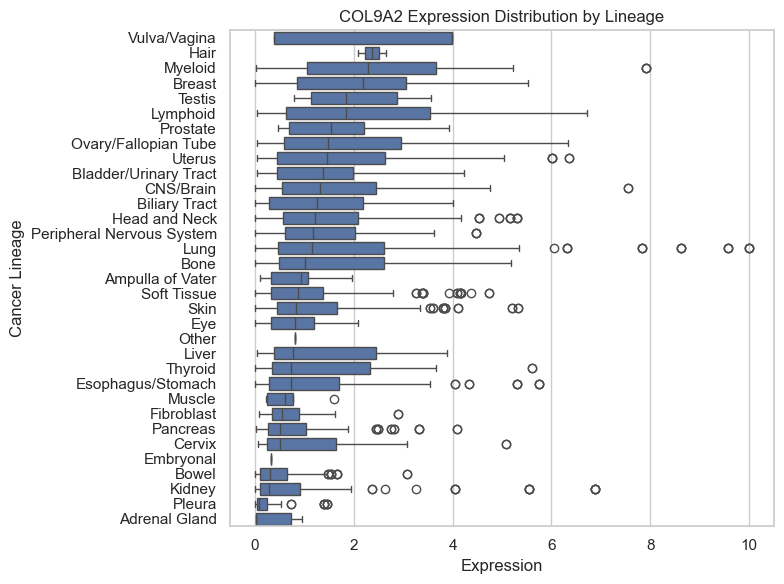

In [44]:
# create gene expression by lineage plot
sns.set(style='whitegrid')


# Compute median expression per lineage
order = merged.groupby('Lineage')['COL9A2'].median().sort_values(ascending=False).index


# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='COL9A2', y='Lineage', order=order, data=merged, legend=False)
plt.title('COL9A2 Expression Distribution by Lineage')
plt.xlabel('Expression')
plt.ylabel('Cancer Lineage')
plt.tight_layout()



In [10]:
# remove lineages with < 10 observations
merged = merged.loc[~merged['Lineage'].isin(['nan','Other','Ampulla of Vater','Hair','Soft Tissue','Fibroblast', 'Embryonal'])]
# remove == 0
merged = merged.loc[merged['COL9A2'] != 0]

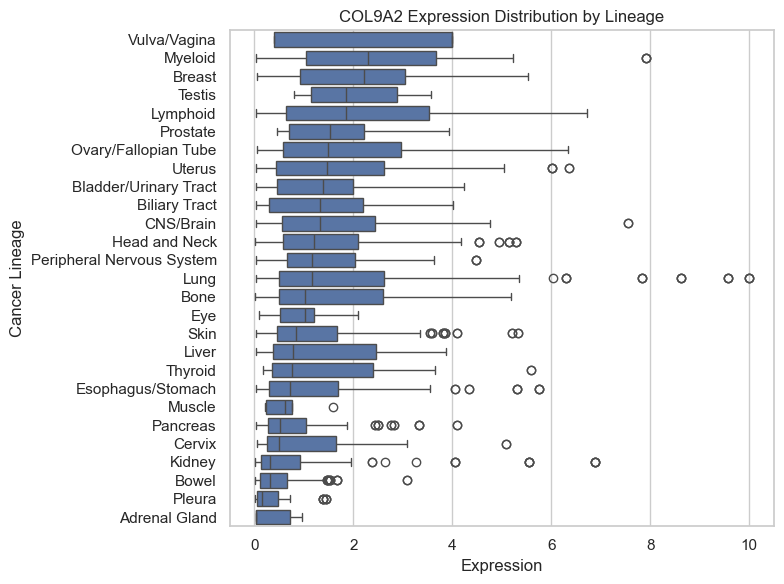

In [11]:
# create gene expression by lineage plot
sns.set(style='whitegrid')


# Compute median expression per lineage
order = merged.groupby('Lineage')['COL9A2'].median().sort_values(ascending=False).index


# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='COL9A2', y='Lineage', order=order, data=merged, legend=False)
plt.title('COL9A2 Expression Distribution by Lineage')
plt.xlabel('Expression')
plt.ylabel('Cancer Lineage')
plt.tight_layout()



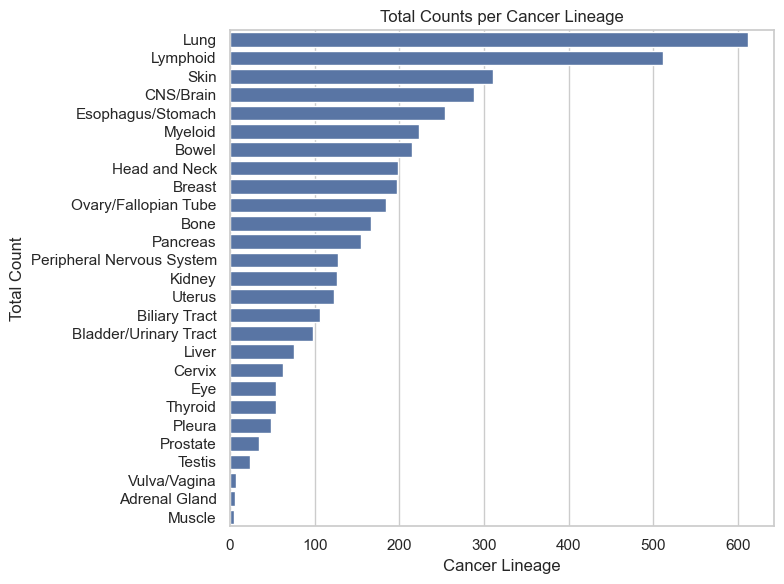

In [13]:
# bar chart showing counts of each

boxplot_order = merged.groupby('Lineage')['COL9A2'].median().sort_values(ascending=False).index


# Count occurrences of each lineage and sort ascending for bar chart
lineage_counts = merged['Lineage'].value_counts().reset_index()
lineage_counts.columns = ['Lineage', 'Count']
bar_order = lineage_counts.sort_values('Count')['Lineage']  # ascending order by count


# Set plot style
sns.set(style="whitegrid")


# Create bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x='Count', y='Lineage', data=lineage_counts)
plt.title('Total Counts per Cancer Lineage')
plt.xlabel('Cancer Lineage')
plt.ylabel('Total Count')
plt.tight_layout()


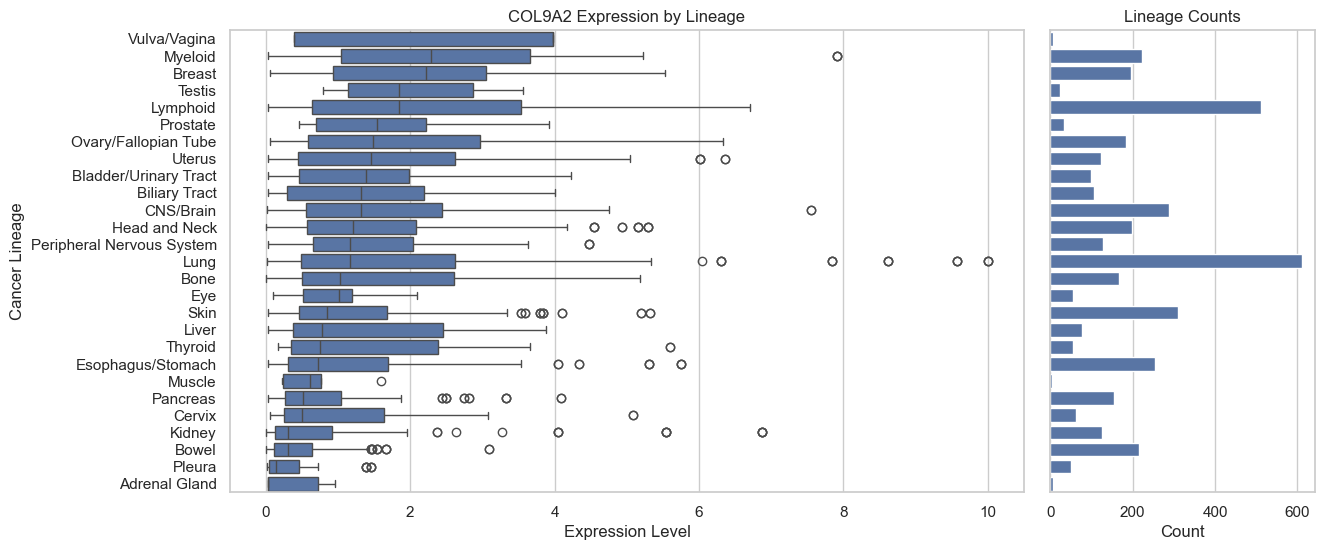

In [14]:

# Create figure with two subplots: boxplot (75%) and bar chart (25%)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [3, 1], 'wspace':0.05})


# Boxplot
sns.boxplot(x='COL9A2', y='Lineage', data=merged, order=order, ax=ax1)
ax1.set_title('COL9A2 Expression by Lineage')
ax1.set_xlabel('Expression Level')
ax1.set_ylabel('Cancer Lineage')
ax1.tick_params(axis='x')


# Bar chart
sns.barplot(x='Count', y='Lineage', data=lineage_counts, order=order, ax=ax2)
ax2.set_title('Lineage Counts')
ax2.set_xlabel('Count')
ax2.tick_params(axis='y', left=False, labelleft=False)  # remove y-axis labels
ax2.set_ylabel('')  # Remove y-axis label
ax2.tick_params(axis='x')
